# Route-Conditioned Repetition Lag-CRP

> Examine transitions through a repeated item after recall enters from the predecessor side of one occurrence's neighborhood.

The route-conditioned repetition CRP analysis examines triples of the form predecessor-side neighbor -> repeater -> next recall. For a repeated item at positions $i$ and $j$, the analysis tracks whether recall enters the repeated item from $i-1$/$i-2$ or $j-1$/$j-2$, then scores the following recall as a lag from either occurrence.

These route-conditioned transitions are the free-recall analogue of the serial-recall run-up test: after recall reaches an occurrence of a repeated item from the predecessor side, does recall continue near that same occurrence or switch toward the other occurrence's neighborhood?

## Workflow

In [1]:
import os

import matplotlib.pyplot as plt

from jaxcmr.analyses.reproutecrp import (
    plot_rep_route_crp,
    subject_rep_route_crp,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
data_paths = [
    "../datasets/prepared/BroitmanKahana2024.h5",
    "../datasets/prepared/LohnasKahana2014.h5",
    "../datasets/prepared/Lohnas2025.h5",
    "../datasets/prepared/HowardKahana2005.h5",
]
trial_queries = [
    "data['listLength'] > 0",
    "data['list_type'] > 2",
    "data['list_type'] == 2",
    "data['condition'] > 0",
]
data_labels = ["BroitmanKahana2024", "LohnasKahana2014", "Lohnas2025", "HowardKahana2005"]
ylim = [0, .45]
figure_dir = "results/figures"
figure_str = ""
min_lag = 4
max_lag = 3
use_lag2 = True
direction_groups = [
    (
        "Entered from 1st-presentation side",
        [("i2i", "Continue near 1st"), ("i2j", "Switch to 2nd")],
    ),
    (
        "Entered from 2nd-presentation side",
        [("j2i", "Switch to 1st"), ("j2j", "Continue near 2nd")],
    ),
]
summary_directions = []# [("same", "Same-route continuation"), ("switch", "Switch-route continuation")]
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
datasets = []
trial_masks = []

for data_path, trial_query in zip(data_paths, trial_queries):
    data_path = os.path.join(project_root, data_path)
    data = load_data(data_path)
    trial_mask = generate_trial_mask(data, trial_query)
    datasets.append(data)
    trial_masks.append(trial_mask)

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


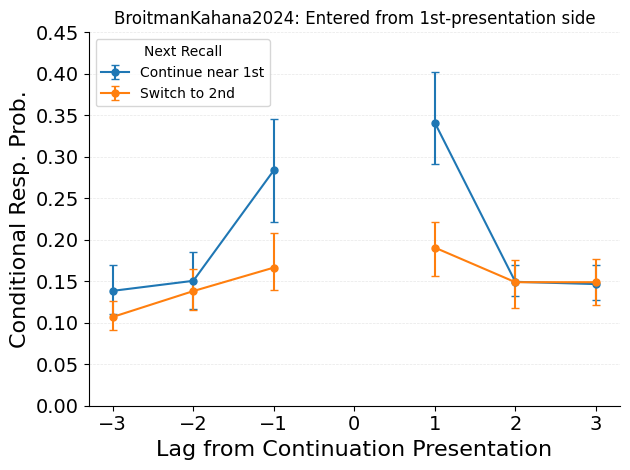

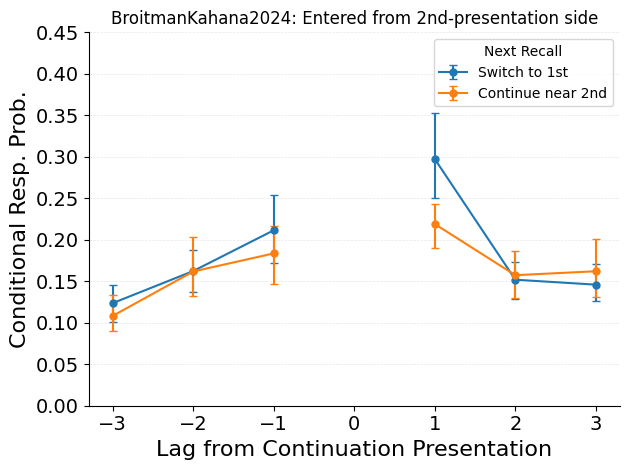

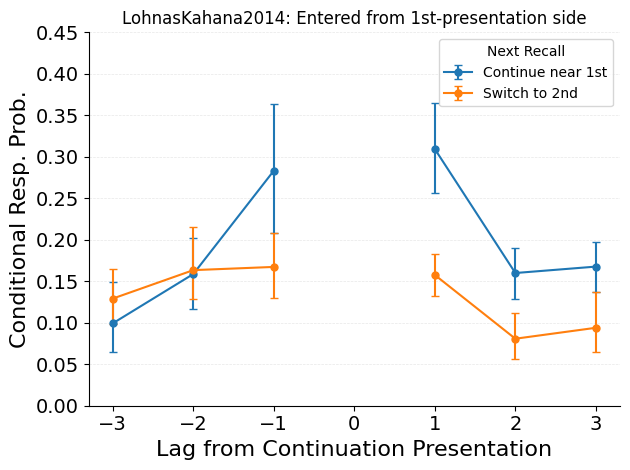

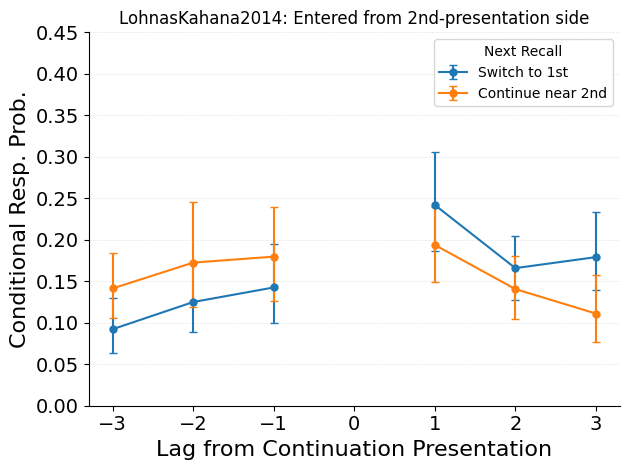

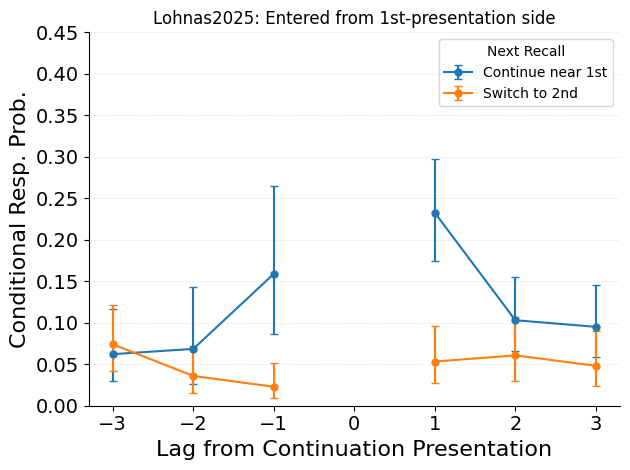

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/stats/_resampling.py:147: RuntimeWarning: invalid value encountered in divide
  a_hat = 1/6 * sum(nums) / sum(dens)**(3/2)


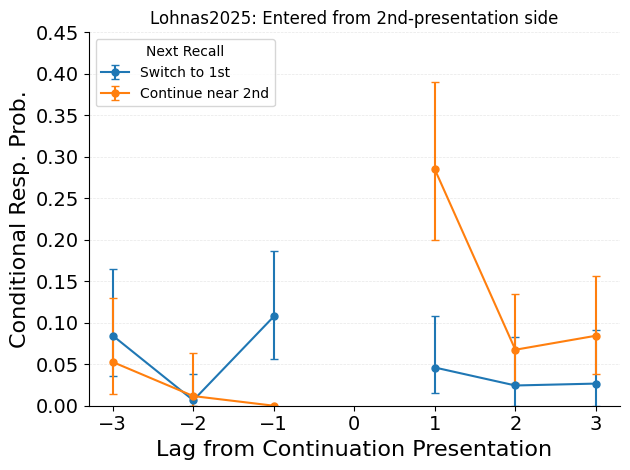

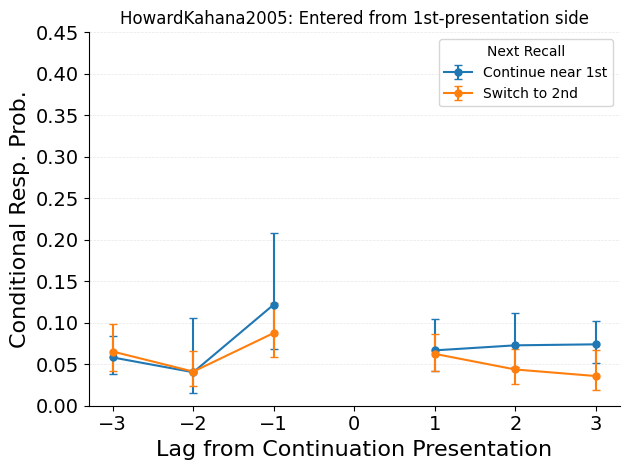

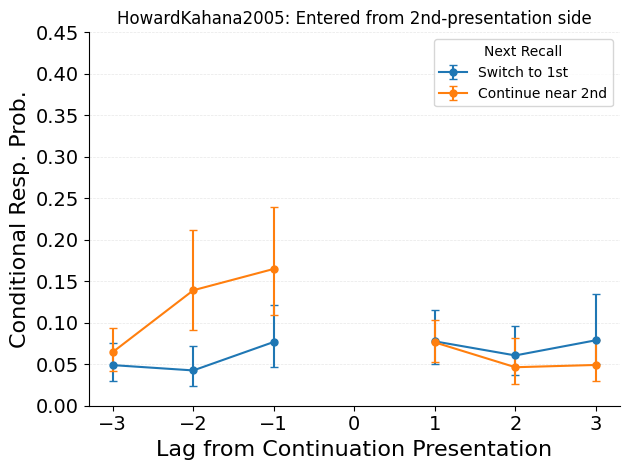

In [4]:
color_cycle = [each["color"] for each in plt.rcParams["axes.prop_cycle"]]

for data_label, data, trial_mask in zip(data_labels, datasets, trial_masks):
    file_label = data_label.replace(" ", "_")
    for group_label, group_directions in direction_groups:
        plt.figure()
        axis = plt.gca()
        for direction_index, (direction, label) in enumerate(group_directions):
            plot_rep_route_crp(
                datasets=data,
                trial_masks=trial_mask,
                max_lag=max_lag,
                min_lag=min_lag,
                direction=direction,
                use_lag2=use_lag2,
                color_cycle=[color_cycle[direction_index % len(color_cycle)]],
                contrast_name="Next Recall",
                labels=[label],
                axis=axis,
            )
        axis.set_xlabel("Lag from Continuation Presentation")
        plt.title(f"{data_label}: {group_label}")
        if ylim is not None:
            for ax in plt.gcf().axes:
                ax.set_ylim(ylim)
        save_figure(figure_dir, figure_str, suffix=f"{file_label}_{'_'.join([direction for direction, _ in group_directions])}")

    for direction, title in summary_directions:
        plot_rep_route_crp(
            datasets=data,
            trial_masks=trial_mask,
            max_lag=max_lag,
            min_lag=min_lag,
            direction=direction,
            use_lag2=use_lag2,
            contrast_name="Source",
            labels=["Data"],
        )
        plt.title(f"{data_label}: {title}")
        if ylim is not None:
            for ax in plt.gcf().axes:
                ax.set_ylim(ylim)
        save_figure(figure_dir, figure_str, suffix=f"{file_label}_{direction}")

## Interpretation

Plots show transition probabilities after recall reaches a repeated item from a predecessor-side occurrence-specific route. Key patterns:

- **Route preservation**: elevated same-route continuations indicate that recall of the repeated item preserves the predecessor-side occurrence route.
- **Route switching**: elevated switch-route continuations indicate that the repeated item acts as a bridge into the other occurrence's neighborhood.
- **Same-switch bias**: a higher same-route curve suggests that the repeated item is not simply erasing the incoming route.

## API Details

### Notebook parameters

- `data_paths` - paths to HDF5 files containing `RecallDataset` objects with repeated items.
- `trial_queries` - queries selecting trials for each dataset.
- `data_labels` - display labels for each dataset.
- `ylim` - y-axis limits shared across datasets, or `None` for automatic scaling.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for saved figures. Leave empty to display without saving.
- `min_lag` - minimum spacing between repeated presentations.
- `max_lag` - maximum lag to display on the x-axis.
- `use_lag2` - whether incoming routes include -2 predecessor-side neighbors as well as -1 neighbors.
- `direction_groups` - incoming-route direction pairs to superimpose.
- `summary_directions` - route-conditioned summary transitions to plot.

### Directions

- `i2i` - i predecessor-side neighbor -> repeater -> lags centered on i.
- `i2j` - i predecessor-side neighbor -> repeater -> lags centered on j.
- `j2i` - j predecessor-side neighbor -> repeater -> lags centered on i.
- `j2j` - j predecessor-side neighbor -> repeater -> lags centered on j.
- `same` - count-combined i2i and j2j.
- `switch` - count-combined i2j and j2i.
- `both` - full 2 x 2 route matrix.